In [9]:
"""
Generate and evaluate random linear-system problems for benchmarking.
Sparsity is the proportion of non-zero elements in the matrix. (0 = dense, 1 = sparse)
"""

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p


_repo_root = _find_repo_root()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from linear_systems_problems.random_matrix_generator_v3 import generate_problem

In [10]:
problem_sizes = [2, 4, 8, 16, 32, 64]
cond_numbers = [1, 5, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 5e6, 1e7, 5e7]
block_fraction_values = [0.1, 0.3, 0.5, 0.7, 0.9]
instances_per_combo = 10

rows = []

for n in problem_sizes:
    for cond_req in cond_numbers:
        for block_frac_req in block_fraction_values:
            requested_block_size = int(np.ceil(block_frac_req * n))
            for seed in range(instances_per_combo):
                prob = generate_problem(
                    n=n,
                    cond_number=cond_req,
                    sparsity=block_frac_req,
                    seed=seed,
                )

                A = prob["A"]
                # Numerical tolerance avoids counting tiny roundoff as non-zero.
                row_nnz = np.count_nonzero(np.abs(A) > 1e-12, axis=1)
                max_row_nnz = int(row_nnz.max())

                rows.append(
                    {
                        "n": n,
                        "requested_condition": cond_req,
                        "actual_condition": prob["condition_number"],
                        "requested_block_fraction": block_frac_req,
                        "requested_block_size": requested_block_size,
                        "returned_block_size": int(prob["block_size"]),
                        "max_row_nnz": max_row_nnz,
                        "row_nnz_within_bound": max_row_nnz <= requested_block_size,
                        "actual_sparsity": prob["sparsity"],
                    }
                )

results_df = pd.DataFrame(rows)
print(f"Generated {len(results_df)} problems")
results_df.tail()

Generated 4800 problems


,n,requested_condition,actual_condition,requested_sparsity,actual_sparsity
4795,64,50000000.0,5.000000e+07,58,0.487793
4796,64,50000000.0,5.000000e+07,58,0.304688
4797,64,50000000.0,5.000000e+07,58,0.358887
4798,64,50000000.0,5.000000e+07,58,0.541504
4799,64,50000000.0,5.000000e+07,58,0.498047


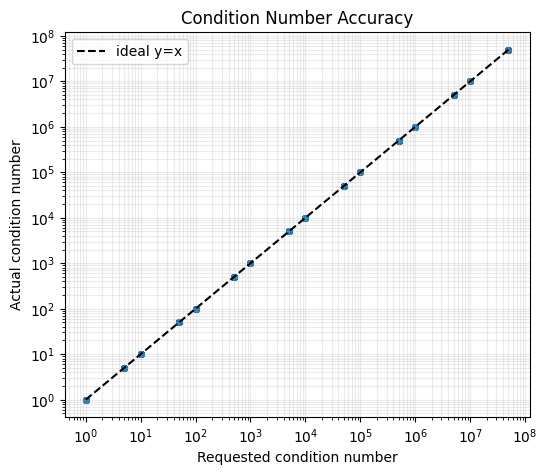

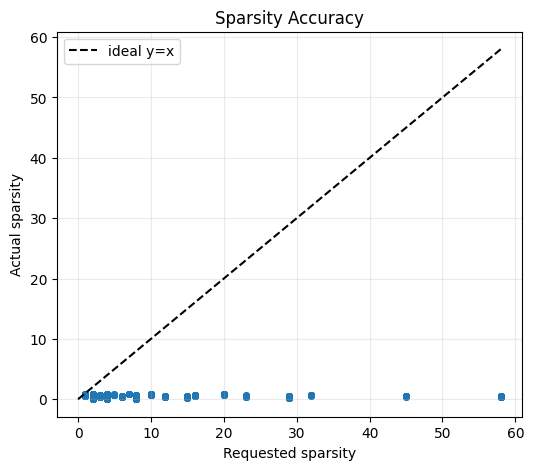

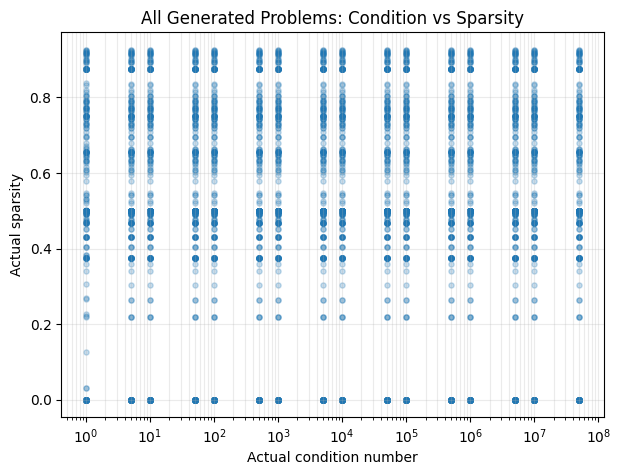

In [11]:
# 1) Requested condition number vs actual condition number
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    results_df["requested_condition"],
    results_df["actual_condition"],
    alpha=0.25,
    s=14,
)
cond_min = min(results_df["requested_condition"].min(), results_df["actual_condition"].min())
cond_max = max(results_df["requested_condition"].max(), results_df["actual_condition"].max())
ax.plot([cond_min, cond_max], [cond_min, cond_max], "k--", lw=1.5, label="ideal y=x")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Requested condition number")
ax.set_ylabel("Actual condition number")
ax.set_title("Condition Number Accuracy")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
plt.show()

# 2) Requested block-size bound vs observed max row non-zeros
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    results_df["requested_block_size"],
    results_df["max_row_nnz"],
    alpha=0.25,
    s=14,
)
b_min = min(results_df["requested_block_size"].min(), results_df["max_row_nnz"].min())
b_max = max(results_df["requested_block_size"].max(), results_df["max_row_nnz"].max())
ax.plot([b_min, b_max], [b_min, b_max], "k--", lw=1.5, label="ideal y=x")
ax.set_xlabel("Requested block-size bound (ceil(fraction * n))")
ax.set_ylabel("Observed max non-zeros per row")
ax.set_title("v3 Structural Bound Accuracy")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

# 3) Requested block fraction vs actual matrix sparsity (not expected to be y=x)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    results_df["requested_block_fraction"],
    results_df["actual_sparsity"],
    alpha=0.15,
    s=12,
    label="instances",
)
mean_curve = (
    results_df.groupby("requested_block_fraction", as_index=False)["actual_sparsity"].mean()
    .sort_values("requested_block_fraction")
)
ax.plot(
    mean_curve["requested_block_fraction"],
    mean_curve["actual_sparsity"],
    color="tab:red",
    marker="o",
    label="mean actual sparsity",
)
ax.set_xlabel("Requested block fraction")
ax.set_ylabel("Actual matrix sparsity (fraction of zeros)")
ax.set_title("v3 Sparsity Response to Block Fraction")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

# 4) Scatter of actual condition numbers and actual sparsities for all generated problems
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    results_df["actual_condition"],
    results_df["actual_sparsity"],
    alpha=0.25,
    s=14,
)
ax.set_xscale("log")
ax.set_xlabel("Actual condition number")
ax.set_ylabel("Actual sparsity")
ax.set_title("All Generated Problems: Condition vs Sparsity")
ax.grid(True, which="both", alpha=0.25)
plt.show()

In [12]:
# Optional quantitative accuracy summary
results_df["cond_ratio"] = results_df["actual_condition"] / results_df["requested_condition"]
results_df["block_bound_slack"] = results_df["requested_block_size"] - results_df["max_row_nnz"]

print("Condition ratio (actual/requested):")
print(results_df["cond_ratio"].describe())

print("\nBlock bound slack = requested_block_size - observed max_row_nnz:")
print(results_df["block_bound_slack"].describe())

violations = (~results_df["row_nnz_within_bound"]).sum()
print(f"\nBound violations: {violations} / {len(results_df)}")

print("\nMean actual sparsity by requested block fraction:")
print(
    results_df.groupby("requested_block_fraction")["actual_sparsity"]
    .mean()
    .sort_index()
)

Condition ratio (actual/requested):
count    4.800000e+03
mean     1.000000e+00
std      5.415007e-10
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: cond_ratio, dtype: float64

Sparsity error (actual-requested):
count    4800.000000
mean      -10.369963
std        13.759902
min       -57.695312
25%       -14.582031
50%        -4.105469
75%        -1.500000
max        -0.125000
Name: sparsity_error, dtype: float64
